# **Predicting the Solubility of Chemical Compounds**

In [22]:
# Load the Delaney solubility dataset
# Dataset source: https://www.kaggle.com/datasets/sorkun/delaney-solubility-with-descriptors
import pandas as pd
df = pd.read_csv("/kaggle/input/delaney-solubility-with-descriptors/delaney_solubility_with_descriptors.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (1144, 5)
Columns: ['MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion', 'logS']


,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.5954,167.850,0.0,0.0,-2.18
1,2.3765,133.405,0.0,0.0,-2.00
2,2.5938,167.850,1.0,0.0,-1.74
3,2.0289,133.405,1.0,0.0,-1.48
4,2.9189,187.375,1.0,0.0,-3.04


## **Data Preparation**

## **Dataset Exploration**

Let's first understand our dataset better by examining its structure, missing values, and basic statistics.

In [23]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# Basic statistical information
print("Dataset statistics:")
print(df.describe())
print("\n" + "="*50 + "\n")

# Check data types
print("Data types:")
print(df.dtypes)

Missing values per column:
MolLogP               0
MolWt                 0
NumRotatableBonds     0
AromaticProportion    0
logS                  0
dtype: int64


Dataset statistics:
           MolLogP        MolWt  NumRotatableBonds  AromaticProportion  \
count  1144.000000  1144.000000        1144.000000         1144.000000   
mean      2.449133   204.631675           2.173951            0.364932   
std       1.866003   102.620500           2.627398            0.343305   
min      -7.571400    16.043000           0.000000            0.000000   
25%       1.414900   122.126000           0.000000            0.000000   
50%       2.340300   183.594500           1.000000            0.375000   
75%       3.406475   270.715750           3.000000            0.666667   
max      10.388600   780.949000          23.000000            1.000000   

              logS  
count  1144.000000  
mean     -3.057997  
std       2.096502  
min     -11.600000  
25%      -4.332250  
50%      -2.870500  
75% 

### Data Loading

In [24]:
y = df["logS"]
y

0      -2.180
1      -2.000
2      -1.740
3      -1.480
4      -3.040
        ...  
1139    1.144
1140   -4.925
1141   -3.893
1142   -3.790
1143   -2.581
Name: logS, Length: 1144, dtype: float64

In [25]:
X = df.drop("logS",axis=1)
X

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


### Data Splitting

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=100)

In [27]:
X_train

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
107,3.14280,112.216,5.0,0.000000
378,-2.07850,142.070,0.0,0.000000
529,-0.47730,168.152,0.0,0.000000
546,-0.86740,154.125,0.0,0.000000
320,1.62150,100.161,2.0,0.000000
...,...,...,...,...
802,3.00254,250.301,1.0,0.842105
53,2.13860,82.146,3.0,0.000000
350,5.76304,256.348,0.0,0.900000
79,3.89960,186.339,10.0,0.000000


In [28]:
X_test

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
822,2.91000,172.268,7.0,0.000000
118,7.27400,360.882,1.0,0.666667
347,1.94040,145.161,0.0,0.909091
1123,1.98640,119.378,0.0,0.000000
924,1.70062,108.140,0.0,0.750000
...,...,...,...,...
1114,1.76210,478.513,4.0,0.000000
427,6.32820,276.338,0.0,1.000000
711,0.04430,218.205,5.0,0.000000
4,2.91890,187.375,1.0,0.000000


## **Model Building**

### Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [30]:
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)


In [31]:
from sklearn.metrics import mean_squared_error, r2_score
lr_train_mse = mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2 = r2_score(y_train,y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2 = r2_score(y_test,y_lr_test_pred)

In [32]:
print("MSE (Train): ",lr_train_mse)
print("R2 (Train): ",lr_train_r2)
print("MSE (Test): ",lr_test_mse)
print("R2 (Test): ",lr_test_r2)

MSE (Train):  1.0075362951093687
R2 (Train):  0.7645051774663391
MSE (Test):  1.0206953660861036
R2 (Test):  0.7891616188563282


### Random Forest

In [33]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=2, random_state=100)

In [34]:
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

In [35]:
rf_train_mse = mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2 = r2_score(y_train,y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2 = r2_score(y_test,y_rf_test_pred)

In [36]:
print("MSE (Train): ",rf_train_mse)
print("R2 (Train): ",rf_train_r2)
print("MSE (Test): ",rf_test_mse)
print("R2 (Test): ",rf_test_r2)

MSE (Train):  1.028227802112806
R2 (Train):  0.7596688824431413
MSE (Test):  1.407688264904896
R2 (Test):  0.7092230211002489


## **Model Performance Visualization**

Let's visualize how well our models perform by plotting predicted vs actual values. A perfect model would show all points on the diagonal line.

Text(0, 0.5, 'Predicted-logS')

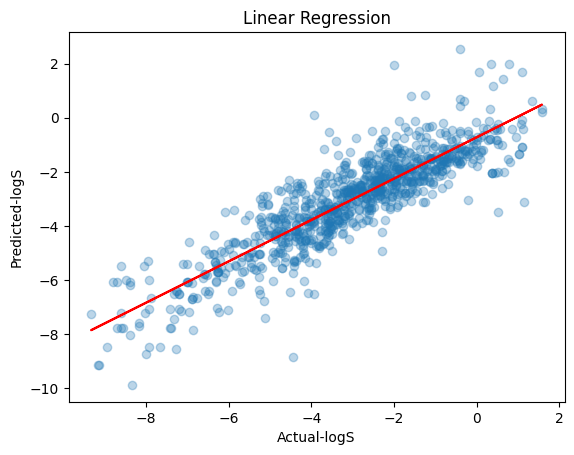

In [37]:
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(x=y_train,y=y_lr_train_pred,alpha=0.3)

z = np.polyfit(y_train,y_lr_train_pred,1)
p = np.poly1d(z)
plt.plot(y_train,p(y_train),c="red")
plt.title("Linear Regression")
plt.xlabel("Actual-logS")
plt.ylabel("Predicted-logS")

Text(0, 0.5, 'Predicted-logS')

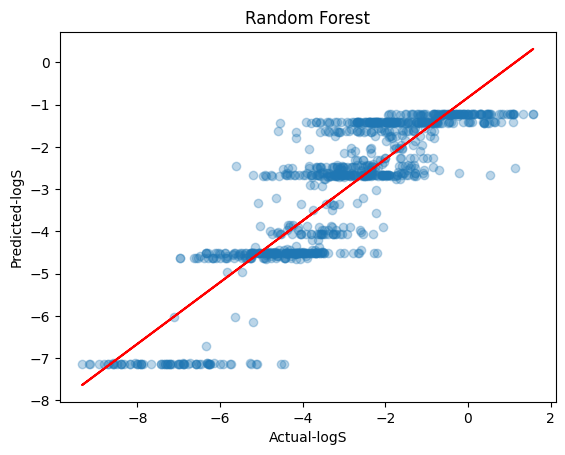

In [38]:
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(x=y_train,y=y_rf_train_pred,alpha=0.3)

z = np.polyfit(y_train,y_rf_train_pred,1)
p = np.poly1d(z)
plt.plot(y_train,p(y_train),c="red")
plt.title("Random Forest")
plt.xlabel("Actual-logS")
plt.ylabel("Predicted-logS")

## Save trained models for later use

This saves the trained models and the feature column order to an `artifacts/` folder.

In [ ]:
import os, json, joblib

ROOT_DIR = "."  # save to project root

# Save models to root
joblib.dump(lr, os.path.join(ROOT_DIR, "linear_regression.joblib"))
joblib.dump(rf, os.path.join(ROOT_DIR, "random_forest.joblib"))

# Save feature column order to root
with open(os.path.join(ROOT_DIR, "feature_columns.json"), "w") as f:
    json.dump({"columns": list(X_train.columns)}, f)

print("Saved:")
print(" -", os.path.join(ROOT_DIR, "linear_regression.joblib"))
print(" -", os.path.join(ROOT_DIR, "random_forest.joblib"))
print(" -", os.path.join(ROOT_DIR, "feature_columns.json"))

Saved:
 - artifacts/linear_regression.joblib
 - artifacts/random_forest.joblib
 - artifacts/feature_columns.json
